In [11]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import os

path1 = os.path.join('data_2025', 'pib2020-2025.csv')
path2 = os.path.join('data_2025', 'Who_life_expectancy.csv')



In [12]:

print("--- 1. Procesando Dataset de la OMS ---")

df_who = pd.read_csv(path2)

# 1. Filtrar por el indicador de interés
df_who_filtered = df_who[df_who['Indicator'] == 'Life expectancy at birth (years)'].copy()

# 2. Filtrar por 'Both sexes'
df_who_filtered = df_who_filtered[df_who_filtered['Dim1'] == 'Both sexes'].copy()

# 3. Limpiar y convertir la columna 'Value'
# Usamos una expresión regular para extraer el primer número (el valor principal)
df_who_filtered['Value_Numeric'] = df_who_filtered['Value'].str.extract(r'(\d+\.?\d*)').astype(float)

# 4. Seleccionar y renombrar las columnas relevantes
df_who_clean = df_who_filtered[['Location', 'Period', 'Value_Numeric']]
df_who_clean.columns = ['Country', 'Year', 'LifeExpectancy']

print("Dataset de la OMS limpio:")
display(df_who_clean)

--- 1. Procesando Dataset de la OMS ---
Dataset de la OMS limpio:


,Country,Year,LifeExpectancy
2,Lesotho,2021,51.5
5,Central African Republic,2021,52.3
6,Somalia,2021,54.0
8,Eswatini,2021,54.6
18,Mozambique,2021,57.7
...,...,...,...
23831,Sweden,2000,79.6
23833,Iceland,2000,79.7
23835,Australia,2000,79.7
23836,Switzerland,2000,79.7


In [13]:
# --- PASO 2: Carga y Transformación de Datos del PIB ---

print("--- 2. Procesando Dataset del PIB ---")
# Cargar el dataset del PIB
df_gdp = pd.read_csv(path1)

# 2. Transformar (Melt) de formato ancho a largo
df_gdp_melted = pd.melt(df_gdp, id_vars=['Country'], var_name='Year', value_name='GDP')

# 3. Limpiar y convertir tipos
df_gdp_melted['Year'] = pd.to_numeric(df_gdp_melted['Year'])
# Convertir GDP a numérico. Los valores faltantes se convertirán en NaN
df_gdp_melted['GDP'] = pd.to_numeric(df_gdp_melted['GDP'], errors='coerce')

print("Dataset del PIB transformado (melted):")
display(df_gdp)


--- 2. Procesando Dataset del PIB ---
Dataset del PIB transformado (melted):


,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0
...,...,...,...,...,...,...,...
191,Vietnam,346310,370076.0,411068.0,433008.0,459472.0,490970.0
192,Palestine,15532,18109.0,19166.0,17848.0,NaN,NaN
193,Yemen,20220,19394.0,23534.0,19412.0,19101.0,17401.0
194,Zambia,18138,22096.0,29164.0,27578.0,26326.0,28910.0


In [14]:
# --- PASO 3: Unión de Datos, Limpieza Final y EDA ---

print("--- 3. Uniendo y Transformando Datos ---")
# 1. Unir los datasets
df_merged = pd.merge(df_who_clean, df_gdp_melted, on=['Country', 'Year'], how='inner')

# 2. Limpieza Final: Eliminar filas con NaN en las columnas clave
df_merged.dropna(subset=['LifeExpectancy', 'GDP'], inplace=True)

# 3. Crear la columna log_GDP
df_merged['log_GDP'] = np.log(df_merged['GDP'])

print(f"Datos combinados y limpios. Total de filas: {len(df_merged)}")
df_merged.describe()


--- 3. Uniendo y Transformando Datos ---
Datos combinados y limpios. Total de filas: 321


,Year,LifeExpectancy,GDP,log_GDP
count,321.000000,321.000000,3.210000e+02,321.000000
mean,2020.498442,71.520561,3.664041e+05,10.676356
std,0.500778,7.324817,1.458291e+06,2.105702
min,2020.000000,51.500000,2.220000e+02,5.402677
25%,2020.000000,66.100000,1.222200e+04,9.410993
50%,2020.000000,72.600000,3.820900e+04,10.550826
75%,2021.000000,76.800000,2.105410e+05,12.257436
max,2021.000000,84.700000,1.819080e+07,16.716427


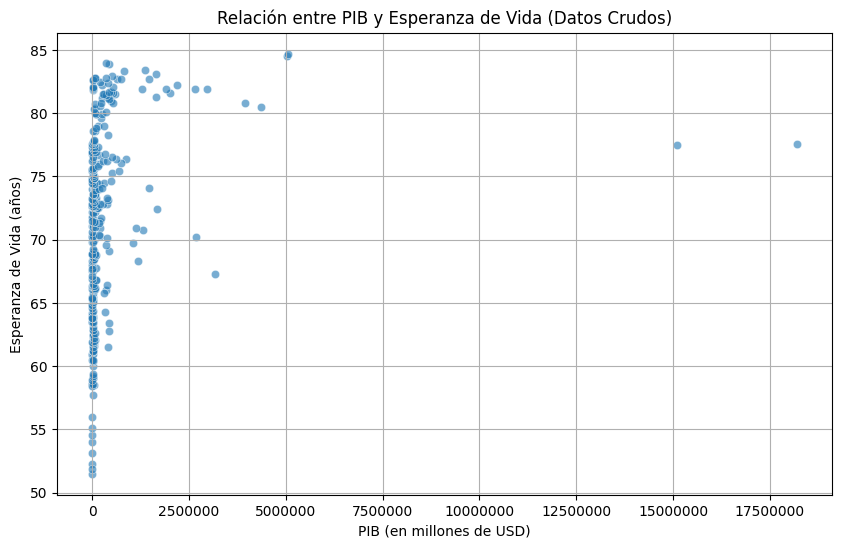

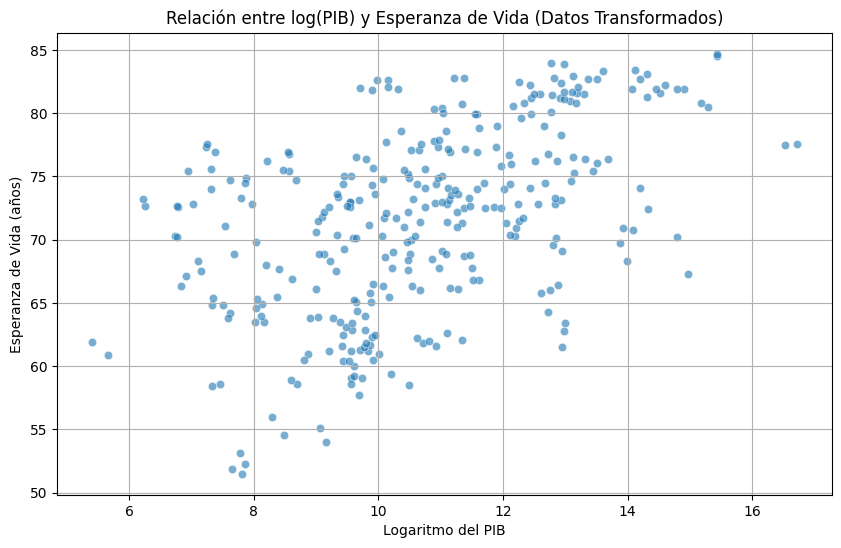

In [15]:
# --- Visualización (EDA) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='GDP', y='LifeExpectancy', alpha=0.6)
plt.title('Relación entre PIB y Esperanza de Vida (Datos Crudos)')
plt.xlabel('PIB (en millones de USD)')
plt.ylabel('Esperanza de Vida (años)')
plt.ticklabel_format(style='plain', axis='x') # Evitar notación científica
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='log_GDP', y='LifeExpectancy', alpha=0.6)
plt.title('Relación entre log(PIB) y Esperanza de Vida (Datos Transformados)')
plt.xlabel('Logaritmo del PIB')
plt.ylabel('Esperanza de Vida (años)')
plt.grid(True)
plt.show()




In [16]:

# --- PASO 4: Análisis de Correlación ---

print("--- 4. Análisis de Correlación ---")
# Seleccionar solo columnas numéricas para la correlación
numeric_cols = ['LifeExpectancy', 'GDP', 'log_GDP']
correlation_matrix = df_merged[numeric_cols].corr(method='pearson')

print("Matriz de Correlación de Pearson:")
print(correlation_matrix)

# Extraer el coeficiente de Pearson específico que usaremos
pearson_coeff = correlation_matrix.loc['log_GDP', 'LifeExpectancy']
print(f"\nCoeficiente de Pearson (log_GDP vs LifeExpectancy): {pearson_coeff:.4f}")



--- 4. Análisis de Correlación ---
Matriz de Correlación de Pearson:
                LifeExpectancy       GDP   log_GDP
LifeExpectancy        1.000000  0.213831  0.505878
GDP                   0.213831  1.000000  0.476837
log_GDP               0.505878  0.476837  1.000000

Coeficiente de Pearson (log_GDP vs LifeExpectancy): 0.5059


--- 4. Análisis de Correlación ---
Matriz de Correlación de Pearson:
                LifeExpectancy       GDP   log_GDP
LifeExpectancy        1.000000  0.213831  0.505878
GDP                   0.213831  1.000000  0.476837
log_GDP               0.505878  0.476837  1.000000

Coeficiente de Pearson (log_GDP vs LifeExpectancy): 0.5059
Generando gráfico 'correlation_heatmap.png'...


<function matplotlib.pyplot.show(close=None, block=None)>

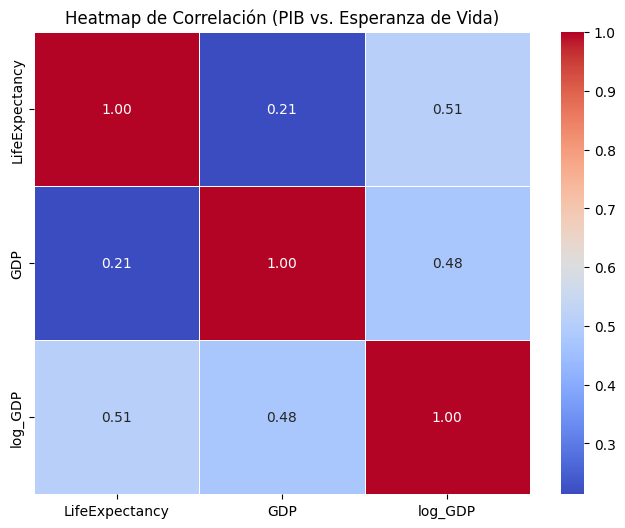

In [26]:
# --- PASO 4: Análisis de Correlación ---

print("--- 4. Análisis de Correlación ---")
# Seleccionar solo columnas numéricas para la correlación
numeric_cols = ['LifeExpectancy', 'GDP', 'log_GDP']
correlation_matrix = df_merged[numeric_cols].corr(method='pearson')

print("Matriz de Correlación de Pearson:")
print(correlation_matrix)

# Extraer el coeficiente de Pearson específico que usaremos
pearson_coeff = correlation_matrix.loc['log_GDP', 'LifeExpectancy']
print(f"\nCoeficiente de Pearson (log_GDP vs LifeExpectancy): {pearson_coeff:.4f}")
print("Generando gráfico 'correlation_heatmap.png'...")
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True,       # Muestra los números dentro de las celdas
    cmap='coolwarm',  # Paleta de colores (rojo=positivo, azul=negativo)
    fmt='.2f',        # Formato de los números a 2 decimales
    linewidths=.5     # Líneas finas entre las celdas
)
plt.title('Heatmap de Correlación (PIB vs. Esperanza de Vida)')
plt.show


In [24]:

print("--- 5. Regresión Lineal ---")

# 1. Definir variables X e y
# Usamos log_GDP como X porque tiene una relación más lineal con y
X = df_merged[['log_GDP']]
y = df_merged['LifeExpectancy']

# 2. División Train/Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} filas")
print(f"Tamaño del conjunto de prueba: {len(X_test)} filas")

# 3. Entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluación del modelo (predicciones sobre el conjunto de prueba)
y_pred = model.predict(X_test)

# Calcular métricas
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 5. Reportar Resultados
print("\n--- Métricas de Evaluación del Modelo ---")
print(f"Coeficiente de Pearson (en todo el dataset): {pearson_coeff:.4f}")
print(f"R-cuadrado (R^2): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


--- 5. Regresión Lineal ---
Tamaño del conjunto de entrenamiento: 272 filas
Tamaño del conjunto de prueba: 49 filas

--- Métricas de Evaluación del Modelo ---
Coeficiente de Pearson (en todo el dataset): 0.5059
R-cuadrado (R^2): 0.3000
Mean Squared Error (MSE): 33.8672
Root Mean Squared Error (RMSE): 5.8196



Generando gráfico 'regression_fit.png'...

--- Análisis Completo Finalizado ---


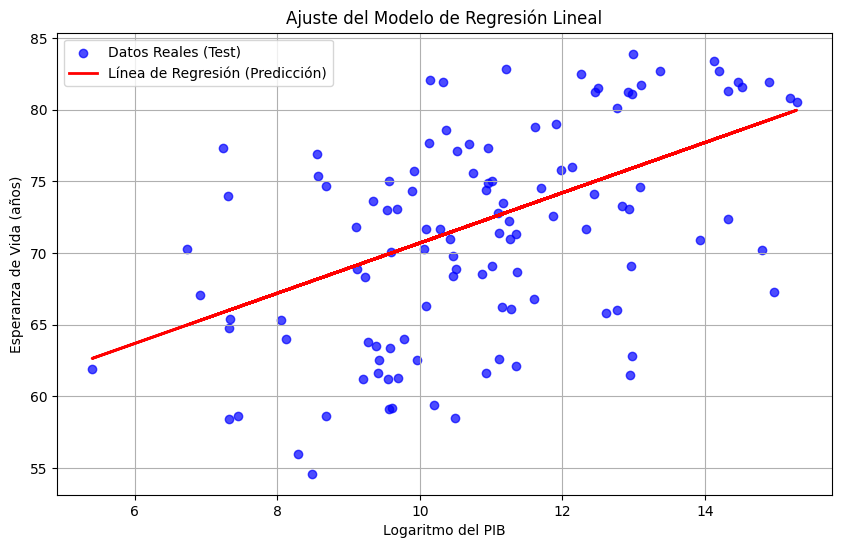

In [19]:
# 6. Visualizar la Regresión
print("\nGenerando gráfico 'regression_fit.png'...")
plt.figure(figsize=(10, 6))
# Dibujar los puntos de datos reales (conjunto de prueba)
plt.scatter(X_test, y_test, color='blue', label='Datos Reales (Test)', alpha=0.7)
# Dibujar la línea de regresión (predicciones)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de Regresión (Predicción)')
plt.title('Ajuste del Modelo de Regresión Lineal')
plt.xlabel('Logaritmo del PIB')
plt.ylabel('Esperanza de Vida (años)')
plt.legend()
plt.grid(True)
plt.show

print("\n--- Análisis Completo Finalizado ---")